# 02: Feature Panel EDA

**Thin client** over `src/factors`. Assembles the `(ticker, month)` panel and inspects it.
All logic lives in `src/factors/{panel,normalize}.py` and `src/data/warehouse.py`.

**Data source:** the Postgres/Timescale **warehouse** (the production source of truth) —
`panel.assemble_panel()` defaults to `source="db"`. Requires `POSTGRES_PASSWORD`
in the environment (and `FACTOR_DB_HOST` if not on the LAN). For an offline run
from the legacy parquet cache, use `panel.assemble_panel(source="cache")`.

Checks: provenance, coverage, point-in-time correctness, normalized-feature ranges, target distribution.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from src.factors import panel
from src.data import cache, db

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 40)

# Provenance: confirm we are reading the warehouse, not stale parquet.
assert db.ping(), "DB unreachable — set POSTGRES_PASSWORD (and FACTOR_DB_HOST if off-LAN)"
prov = db.read_sql(
    "SELECT (SELECT count(*) FROM prices) AS prices, "
    "(SELECT count(*) FROM fundamental_features) AS fundamental_features, "
    "(SELECT count(*) FROM universe WHERE is_active) AS investable"
)
print('warehouse rows:', prov.to_dict('records')[0])

p = panel.assemble_panel()          # source="db" by default
cache.save(p, 'panel.parquet')      # downstream stages load this
print('panel shape:', p.shape)
print('date range:', p.date.min().date(), '->', p.date.max().date())
print('tickers:', p.ticker.nunique(), '| sectors:', p.gics_sector.nunique())
p.head()

warehouse rows: {'prices': 740491, 'fundamental_features': 151894, 'investable': 3976}


panel shape: (1256416, 22)
date range: 2000-02-29 -> 2026-05-31
tickers: 3976 | sectors: 11


,date,ticker,gics_sector,forward_return,market_cap,momentum_12_2,momentum_6_1,volatility_12m,size_log_mktcap,earnings_yield,book_to_price,ev_ebitda_inv,roe,gross_margin,profit_margin,accruals,revenue_growth_yoy,asset_growth_yoy,yield_curve,vix,hy_spread,target
0,2000-02-29,A,NaN,0.001204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-02-29,AA,NaN,0.025548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-02-29,AAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-02-29,AAMI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-02-29,AAOI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature coverage over time

In [2]:
from src.factors.panel import _feature_list
feats = _feature_list()

# Non-null coverage per feature, recent window
recent = p[p.date >= '2015-01-01']
cov = (recent[feats].notna().mean() * 100).round(0).sort_values()
print('Feature coverage (% non-null, 2015+):')
print(cov.to_string())

Feature coverage (% non-null, 2015+):
gross_margin          16.0
hy_spread             19.0
profit_margin         31.0
revenue_growth_yoy    33.0
earnings_yield        39.0
ev_ebitda_inv         39.0
book_to_price         41.0
size_log_mktcap       43.0
accruals              46.0
roe                   51.0
momentum_12_2         56.0
volatility_12m        56.0
asset_growth_yoy      56.0
momentum_6_1          57.0
yield_curve           59.0
vix                   59.0


## Point-in-time correctness
Normalized features are cross-sectional ranks in [0, 1]; the target is a within-sector forward-return rank.

Normalized features are valid cross-sectional ranks in [0,1].


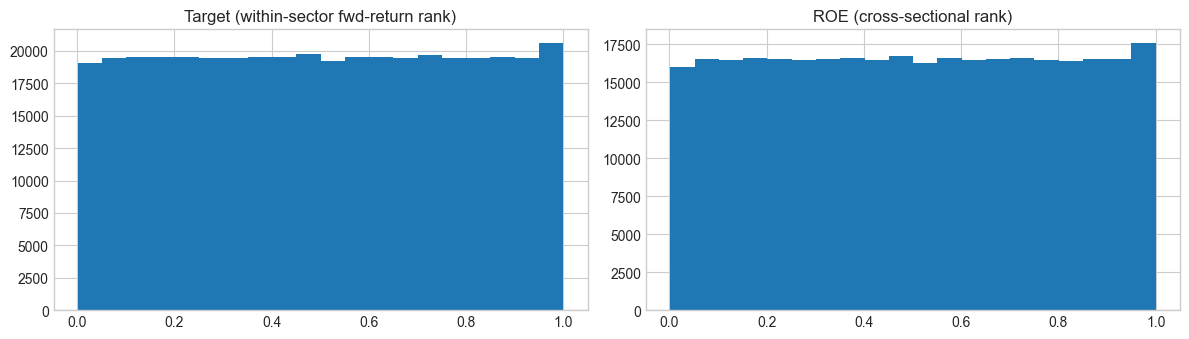

In [3]:
# Rank features must lie in [0,1]
for c in ['roe', 'momentum_12_2', 'book_to_price']:
    s = p[c].dropna()
    assert s.min() >= 0 and s.max() <= 1.0001, f'{c} not a rank'
print('Normalized features are valid cross-sectional ranks in [0,1].')

# Target distribution should be ~uniform (it is a rank)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
p['target'].dropna().hist(bins=20, ax=ax[0]); ax[0].set_title('Target (within-sector fwd-return rank)')
p['roe'].dropna().hist(bins=20, ax=ax[1]); ax[1].set_title('ROE (cross-sectional rank)')
plt.tight_layout(); plt.show()

In [4]:
# Rows usable for modeling: target + at least the core features present
core = ['momentum_12_2', 'volatility_12m', 'roe', 'book_to_price', 'earnings_yield']
usable = p.dropna(subset=['target'] + core)
print(f'Usable (target + core features) rows: {len(usable)} '
      f'({len(usable)/len(p)*100:.0f}% of panel)')
print('Usable date range:', usable.date.min().date(), '->', usable.date.max().date())
print('Avg names per month (usable):', round(usable.groupby('date').size().mean(), 1))

Usable (target + core features) rows: 237773 (19% of panel)
Usable date range: 2009-06-30 -> 2026-04-30
Avg names per month (usable): 1171.3


## Notes

- The panel is built from the full investable universe in the warehouse (one row per `(ticker, month)`); coverage densifies in the recent window where fundamentals exist.
- The assembled panel is cached to `data/processed/panel.parquet` for stages 3-5.
- **Next**: `notebooks/03_signal_ic.ipynb` — single-signal Information Coefficient analysis.